# Exploratory Data Analysis (EDA) and Visualizations

This notebook focuses on performing **Exploratory Data Analysis (EDA)** and creating **visualizations** to better understand the dataset of customer reviews for Tunisian telecom providers. Here's a breakdown of what we are doing:

1. **Imports and Setup**:
    - We import necessary libraries like `pandas`, `matplotlib`, and `seaborn` for data manipulation and visualization.
    - We set a clean and consistent style for our charts using Seaborn.

2. **Loading the Data**:
    - The dataset is loaded from the `data/01_raw/` directory.
    - We check if the file exists and print the shape of the dataset to confirm successful loading.

3. **High-Level Statistics**:
    - We display the number of reviews per company to get an overview of the dataset distribution.

4. **Visualizations**:
    - **Score Distribution**: A bar chart showing the distribution of customer ratings (1-5 stars). We use a color palette to highlight positive (green), neutral (yellow), and negative (red) ratings.
    - **Company Comparison**: A bar chart comparing the volume of reviews for each telecom company.

5. **Language Insights**:
    - We print 20 random reviews to observe the mixed-language nature of the dataset (French, Arabic, and Tunisian Derja). This helps us understand the preprocessing challenges ahead.

This notebook sets the stage for deeper analysis and modeling by providing a clear understanding of the dataset's structure and key characteristics.

Data Loaded! Shape: (23931, 6)

Reviews per Company:
company
Ooredoo    12782
Orange      7289
MyTT        3860
Name: count, dtype: int64


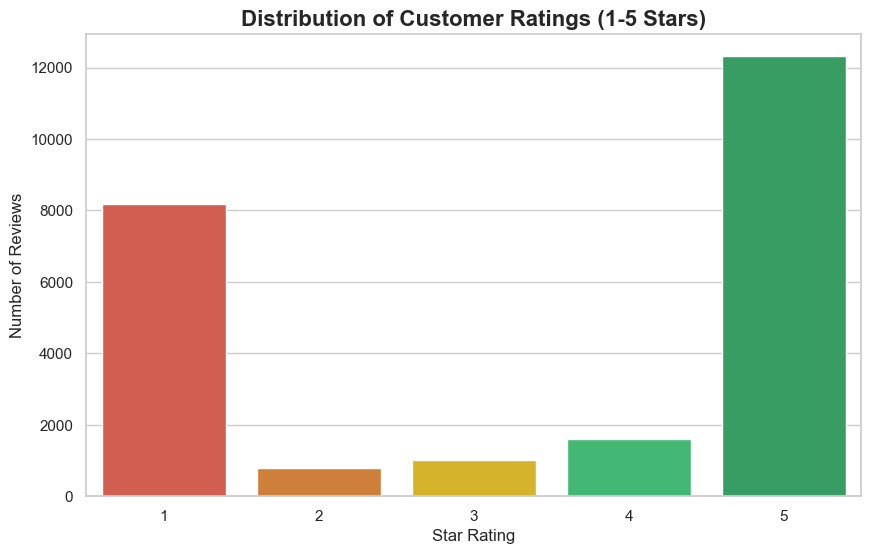

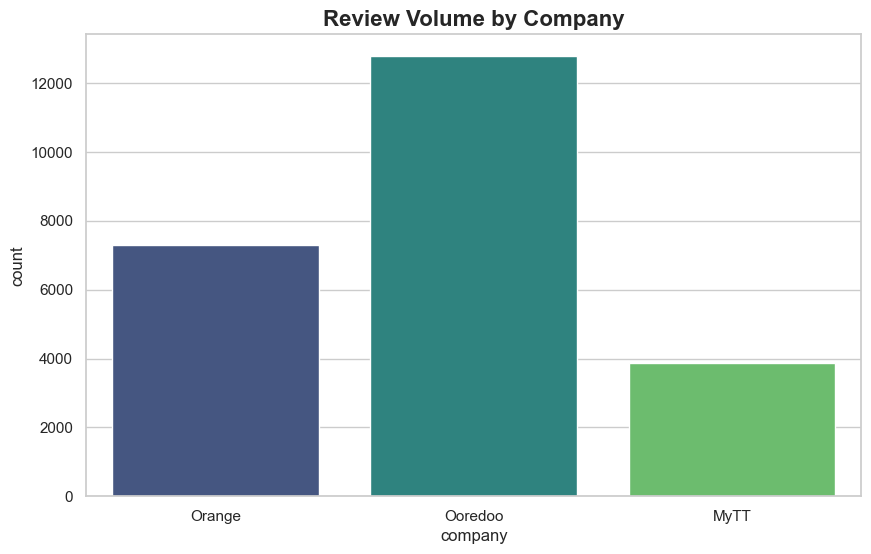


RANDOM REVIEW SAMPLES (Look at the language mix!):
1. Bien
------------------------------------------------------------
2. Merci orange
------------------------------------------------------------
3. Si vous mettiez la même énergie à développer et maintenir vos applications que celle que vous mettez à spam vos abonnés par SMS on aurais eu une application qui fonctionne. Une vrai daube qui ne fonctionne qu'une fois tout les 6 essais voir plus.
------------------------------------------------------------
4. Application nulle , toujours indisponible, chaque fois c pas pas mon numéro qui est affiché !!!! Je me connecte de nouveau et ça marche pas 😡😡😡😡😡😡😡
------------------------------------------------------------
5. ❤❤❤❤👍👍👍👍
------------------------------------------------------------
6. Good
------------------------------------------------------------
7. Se désabonner de tous les offres
------------------------------------------------------------
8. Bien
--------------------------------

In [2]:
# notebooks/02_eda_visuals.ipynb

# 1. Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set a nice style for our charts
sns.set_theme(style="whitegrid")

# 2. Load the Data
RAW_DATA_PATH = "../data/01_raw/tunisian_telco_reviews_raw.csv"

if os.path.exists(RAW_DATA_PATH):
    df = pd.read_csv(RAW_DATA_PATH)
    print(f"Data Loaded! Shape: {df.shape}")
else:
    print("--- File not found. Check your path!")

# 3. The "Big Picture" Stats
print("\nReviews per Company:")
print(df['company'].value_counts())

# 4. Visual 1: Score Distribution (The "Happiness" Chart)
plt.figure(figsize=(10, 6))
# We map 1-2 to Red, 3 to Yellow, 4-5 to Green
palette = {1: "#e74c3c", 2: "#e67e22", 3: "#f1c40f", 4: "#2ecc71", 5: "#27ae60"}

sns.countplot(data=df, x='score', hue='score', palette=palette, legend=False)
plt.title("Distribution of Customer Ratings (1-5 Stars)", fontsize=16, fontweight='bold')
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()

# 5. Visual 2: Company Comparison
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='company', hue='company', palette="viridis")
plt.title("Review Volume by Company", fontsize=16, fontweight='bold')
plt.show()

# 6. The "Tunisian Reality" Check (The most important part!)
# Let's print 20 random reviews to see the language mess.
print("\nRANDOM REVIEW SAMPLES (Look at the language mix!):")
print("="*60)
sample_reviews = df['content'].sample(20, random_state=42).values

for i, review in enumerate(sample_reviews):
    print(f"{i+1}. {review}\n{'-'*60}")